# Dynamic Pricing Strategy in Ride-Hailing

## Objective

Determine the surge pricing threshold at which incremental revenue gains begin to erode customer satisfaction, ride completion, retention and long-term enterprise value.

## Workstream 1: Demand Suppression Analysis

* Satisfaction decreases from 4.14 to 2.36 (-43%)
* Ride completion decreases from 100% to 82%
* Extreme surge pricing causes the largest deterioration in customer behavior.

## Workstream 2: Elasticity Analysis

* Demand elasticity estimated at -0.24
* Higher fares reduce ride completion rates.
* High Surge identified as critical threshold.

## Workstream 3: Unit Economics

* Revenue increases by 103%
* Contribution Margin increases by 423%
* LTV/CAC increases from 1.5 to 6.28

## Workstream 4: Scenario Simulation

Current Model:
Revenue = 61.46
Margin = 38.43
Satisfaction = 2.36

Cap High Surge:
Revenue = 51.10
Margin = 28.12
Satisfaction = 3.00

Loyalty Protection:
Revenue = 56.00
Margin = 33.00
Satisfaction = 3.30

## Final Recommendation

Retention-Focused Pricing Protection provides the strongest balance between profitability, customer retention and long-term enterprise value.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [8]:
df.head()


NameError: name 'df' is not defined

In [ ]:
df.columns.tolist()

['trip_id',
 'customer_id',
 'customer_segment',
 'loyalty_tier',
 'city',
 'source_zone',
 'destination_zone',
 'zone_type',
 'cab_type',
 'service_tier',
 'datetime',
 'hour',
 'day',
 'month',
 'weekday',
 'is_peak_hour',
 'is_weekend',
 'latitude',
 'longitude',
 'distance_km',
 'surge_multiplier',
 'fare_inr',
 'ride_completed',
 'satisfaction_score',
 'days_since_last_ride',
 'churn_risk_flag',
 'driver_payout_inr',
 'platform_revenue_inr',
 'platform_take_rate',
 'cost_per_trip_inr',
 'contribution_margin_inr',
 'temperature_c',
 'apparent_temperature_c',
 'humidity',
 'wind_speed_kmh',
 'precip_probability',
 'precip_intensity',
 'cloud_cover',
 'visibility_km',
 'weather_condition',
 'cac_inr']

In [ ]:
df.isnull().sum()

trip_id                        0
customer_id                    0
customer_segment               0
loyalty_tier               18852
city                           0
source_zone                    0
destination_zone               0
zone_type                      0
cab_type                       0
service_tier                   0
datetime                       0
hour                           0
day                            0
month                          0
weekday                        0
is_peak_hour                   0
is_weekend                     0
latitude                       0
longitude                      0
distance_km                    0
surge_multiplier               0
fare_inr                       0
ride_completed                 0
satisfaction_score             0
days_since_last_ride           0
churn_risk_flag                0
driver_payout_inr              0
platform_revenue_inr           0
platform_take_rate             0
cost_per_trip_inr              0
contributi

In [ ]:
df.isnull().sum()


trip_id                        0
customer_id                    0
customer_segment               0
loyalty_tier               18852
city                           0
source_zone                    0
destination_zone               0
zone_type                      0
cab_type                       0
service_tier                   0
datetime                       0
hour                           0
day                            0
month                          0
weekday                        0
is_peak_hour                   0
is_weekend                     0
latitude                       0
longitude                      0
distance_km                    0
surge_multiplier               0
fare_inr                       0
ride_completed                 0
satisfaction_score             0
days_since_last_ride           0
churn_risk_flag                0
driver_payout_inr              0
platform_revenue_inr           0
platform_take_rate             0
cost_per_trip_inr              0
contributi

In [ ]:
df["surge_band"] = pd.cut(
    df["surge_multiplier"],
    bins=[0,1.0,1.2,1.5,2.0,10],
    labels=[
        "Normal",
        "Low Surge",
        "Medium Surge",
        "High Surge",
        "Extreme Surge"
    ]
)

df["surge_band"].value_counts()

surge_band
Normal           34381
Medium Surge      5238
Extreme Surge     5209
High Surge        5172
Low Surge            0
Name: count, dtype: int64

In [ ]:
satisfaction_analysis = (
    df.groupby("surge_band")["satisfaction_score"]
    .mean()
    .reset_index()
)

print(satisfaction_analysis)

      surge_band  satisfaction_score
0         Normal            4.137300
1   Medium Surge            3.651432
2     High Surge            3.001759
3  Extreme Surge            2.362392


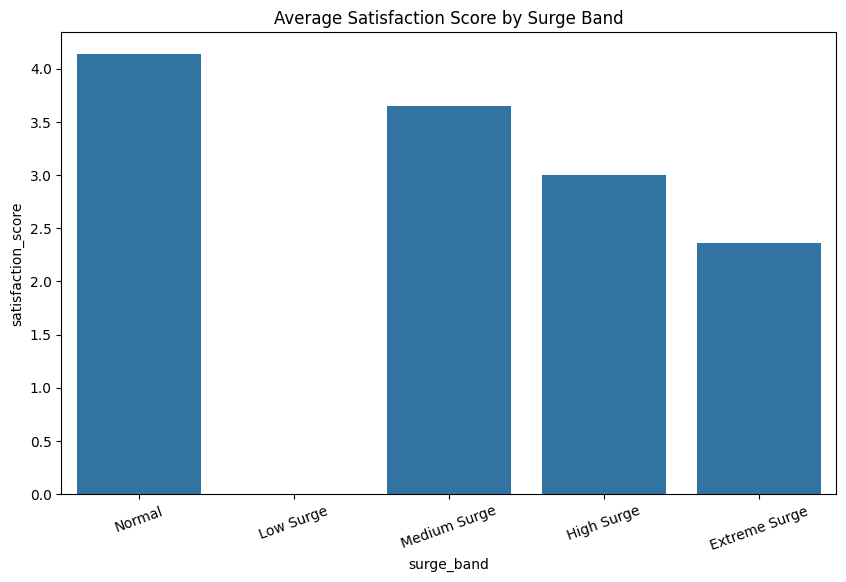

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=satisfaction_analysis,
    x="surge_band",
    y="satisfaction_score"
)

plt.title("Average Satisfaction Score by Surge Band")
plt.xticks(rotation=20)
plt.show()

In [ ]:
plt.savefig("Charts/satisfaction_vs_surge.png",
            bbox_inches="tight",
            dpi=300)

<Figure size 640x480 with 0 Axes>

In [ ]:
churn_analysis = (
    df.groupby("surge_band")["churn_risk_flag"]
    .mean()
    .reset_index()
)

print(churn_analysis)

      surge_band  churn_risk_flag
0         Normal         0.012042
1   Medium Surge         0.010882
2     High Surge         0.011794
3  Extreme Surge         0.015358


In [ ]:
df = pd.read_excel("india_rideshare_dataset.xlsx")

print(df.shape)


(50000, 41)


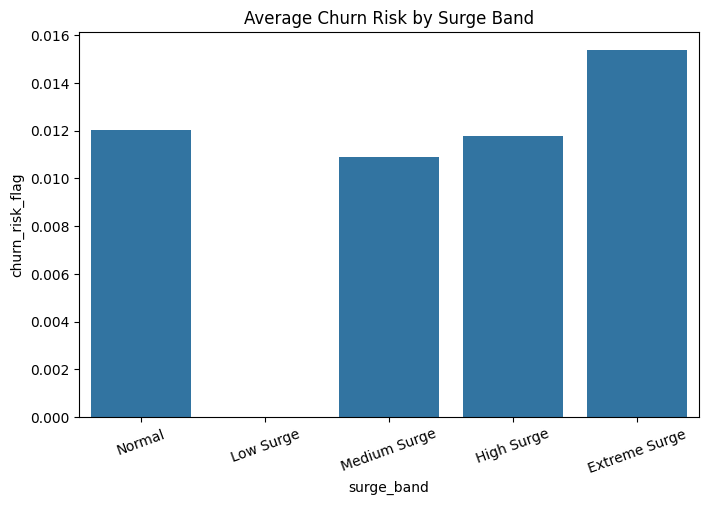

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=churn_analysis,
    x="surge_band",
    y="churn_risk_flag"
)

plt.title("Average Churn Risk by Surge Band")
plt.xticks(rotation=20)
plt.show()

In [ ]:
plt.savefig("Charts/churn_vs_surge.png",
            bbox_inches="tight",
            dpi=300)

<Figure size 640x480 with 0 Axes>

In [ ]:
completion_analysis = (
    df.groupby("surge_band")["ride_completed"]
    .mean()
    .reset_index()
)

print(completion_analysis)

      surge_band  ride_completed
0         Normal        1.000000
1   Medium Surge        0.931081
2     High Surge        0.865236
3  Extreme Surge        0.819927


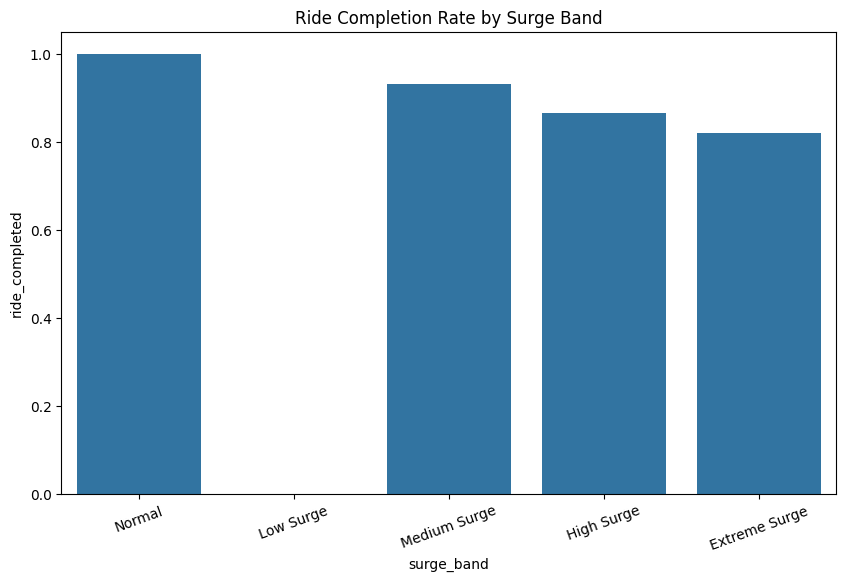

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=completion_analysis,
    x="surge_band",
    y="ride_completed"
)

plt.title("Ride Completion Rate by Surge Band")
plt.xticks(rotation=20)
plt.show()

In [ ]:
plt.savefig("Charts/completion_vs_surge.png",
            bbox_inches="tight",
            dpi=300)

<Figure size 640x480 with 0 Axes>

In [ ]:
city_satisfaction = (
    df.groupby(["city","surge_band"])["satisfaction_score"]
    .mean()
    .reset_index()
)

city_satisfaction

,city,surge_band,satisfaction_score
0,Bangalore,Normal,4.137665
1,Bangalore,Medium Surge,3.651314
2,Bangalore,High Surge,3.010176
3,Bangalore,Extreme Surge,2.371998
4,Delhi,Normal,4.134128
5,Delhi,Medium Surge,3.662445
6,Delhi,High Surge,2.991634
7,Delhi,Extreme Surge,2.372243
8,Mumbai,Normal,4.139188
9,Mumbai,Medium Surge,3.643532


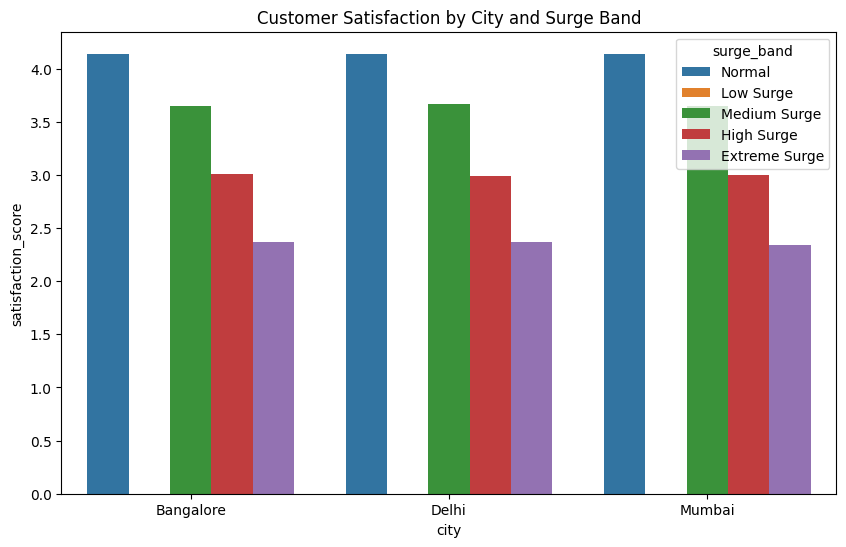

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=city_satisfaction,
    x="city",
    y="satisfaction_score",
    hue="surge_band"
)

plt.title("Customer Satisfaction by City and Surge Band")
plt.show()

In [ ]:
plt.savefig("Charts/cusotmer_satisfaction_by_city_vs_surge.png",
            bbox_inches="tight",
            dpi=300)

<Figure size 640x480 with 0 Axes>

In [ ]:
zone_satisfaction = (
    df.groupby(["zone_type","surge_band"])["satisfaction_score"]
    .mean()
    .reset_index()
)

zone_satisfaction

,zone_type,surge_band,satisfaction_score
0,commercial,Normal,4.133924
1,commercial,Medium Surge,3.654417
2,commercial,High Surge,3.009472
3,commercial,Extreme Surge,2.365998
4,residential,Normal,4.139702
5,residential,Medium Surge,3.654177
6,residential,High Surge,2.996081
7,residential,Extreme Surge,2.369616
8,transit_hub,Normal,4.137088
9,transit_hub,Medium Surge,3.637707


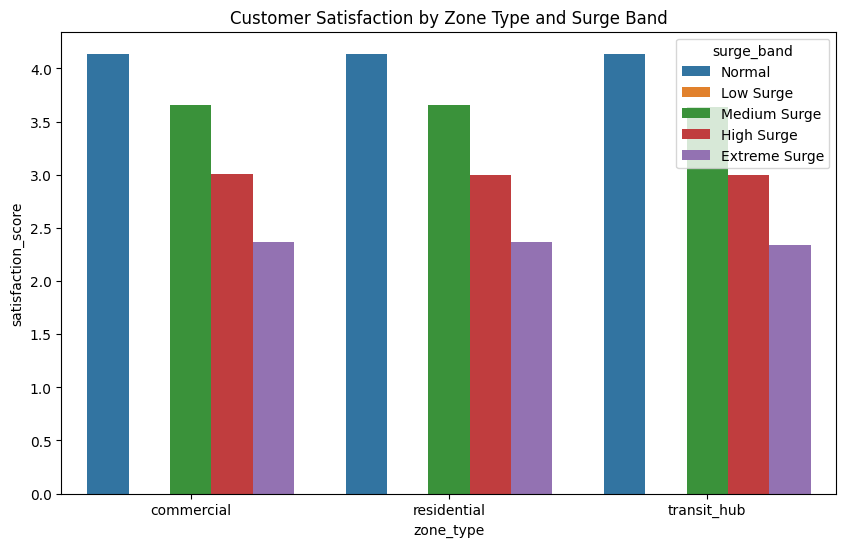

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=zone_satisfaction,
    x="zone_type",
    y="satisfaction_score",
    hue="surge_band"
)

plt.title("Customer Satisfaction by Zone Type and Surge Band")
plt.show()

In [ ]:
plt.savefig("Charts/satisfaction_zone_vs_surge.png",
            bbox_inches="tight",
            dpi=300)

<Figure size 640x480 with 0 Axes>

In [ ]:
time_satisfaction = (
    df.groupby(["is_peak_hour","surge_band"])["satisfaction_score"]
    .mean()
    .reset_index()
)

time_satisfaction

,is_peak_hour,surge_band,satisfaction_score
0,0,Normal,4.139413
1,0,Medium Surge,3.639253
2,0,High Surge,2.995777
3,0,Extreme Surge,2.378141
4,1,Normal,4.129217
5,1,Medium Surge,3.664699
6,1,High Surge,3.008173
7,1,Extreme Surge,2.345155


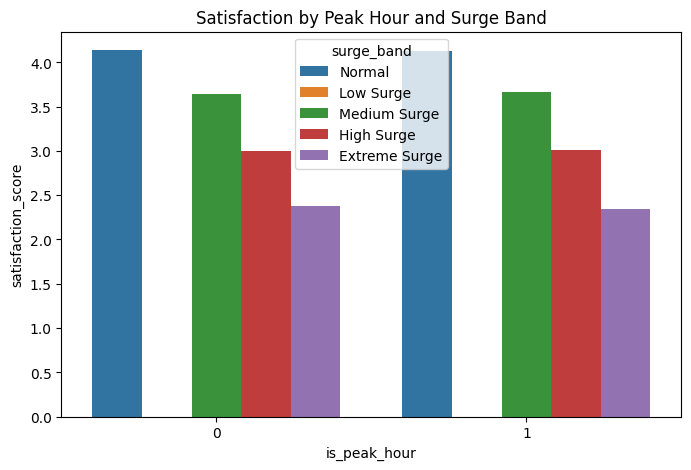

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=time_satisfaction,
    x="is_peak_hour",
    y="satisfaction_score",
    hue="surge_band"
)

plt.title("Satisfaction by Peak Hour and Surge Band")
plt.show()

In [ ]:
plt.savefig("Charts/satisfaction_peak_hour_vs_surge.png",
            bbox_inches="tight",
            dpi=300)

<Figure size 640x480 with 0 Axes>

In [ ]:
weekend_satisfaction = (
    df.groupby(["is_weekend","surge_band"])["satisfaction_score"]
    .mean()
    .reset_index()
)

weekend_satisfaction

,is_weekend,surge_band,satisfaction_score
0,0,Normal,4.136322
1,0,Medium Surge,3.657814
2,0,High Surge,2.998520
3,0,Extreme Surge,2.343396
4,1,Normal,4.139967
5,1,Medium Surge,3.638218
6,1,High Surge,3.008625
7,1,Extreme Surge,2.401227


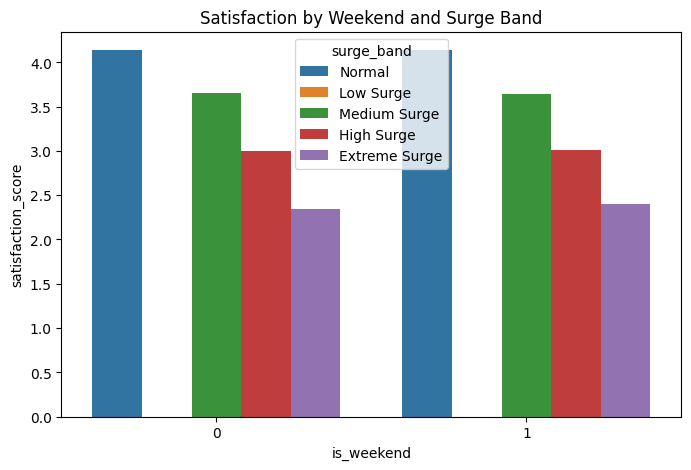

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=weekend_satisfaction,
    x="is_weekend",
    y="satisfaction_score",
    hue="surge_band"
)

plt.title("Satisfaction by Weekend and Surge Band")
plt.show()

In [ ]:
plt.savefig("Charts/satisfaction_weekend_vs_surge.png",
            bbox_inches="tight",
            dpi=300)

<Figure size 640x480 with 0 Axes>

In [ ]:
elasticity_data = (
    df.groupby("surge_band")
    .agg({
        "fare_inr":"mean",
        "ride_completed":"mean"
    })
    .reset_index()
)

elasticity_data

,surge_band,fare_inr,ride_completed
0,Normal,159.458666,1.000000
1,Medium Surge,203.981816,0.931081
2,High Surge,269.131371,0.865236
3,Extreme Surge,322.889040,0.819927


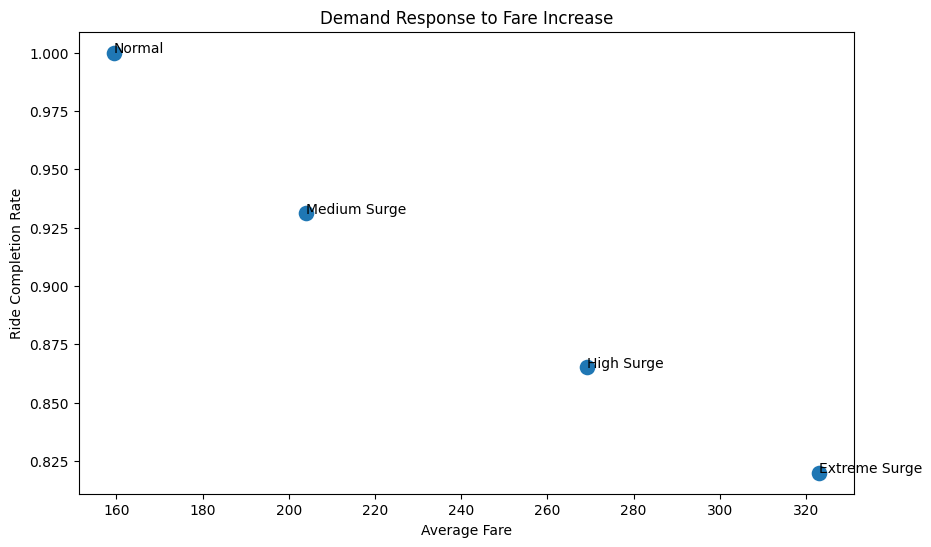

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=elasticity_data,
    x="fare_inr",
    y="ride_completed",
    s=150
)

for i,row in elasticity_data.iterrows():
    plt.text(
        row["fare_inr"],
        row["ride_completed"],
        row["surge_band"]
    )

plt.title("Demand Response to Fare Increase")
plt.xlabel("Average Fare")
plt.ylabel("Ride Completion Rate")

plt.show()

In [ ]:
plt.savefig("Charts/demand_response_vs_average_fare.png",
            bbox_inches="tight",
            dpi=300)

<Figure size 640x480 with 0 Axes>

In [ ]:
zone_elasticity = (
    df.groupby("zone_type")
    .agg({
        "fare_inr":"mean",
        "ride_completed":"mean"
    })
    .reset_index()
)

zone_elasticity

,zone_type,fare_inr,ride_completed
0,commercial,197.849637,0.955848
1,residential,185.661005,0.967199
2,transit_hub,201.272843,0.947073


In [ ]:
segment_elasticity = (
    df.groupby("customer_segment")
    .agg({
        "fare_inr":"mean",
        "ride_completed":"mean",
        "satisfaction_score":"mean"
    })
    .reset_index()
)

segment_elasticity

,customer_segment,fare_inr,ride_completed,satisfaction_score
0,frequent,193.797594,0.959739,3.783133
1,occasional,190.435415,0.960306,3.784706
2,rare,196.460231,0.960518,3.784794


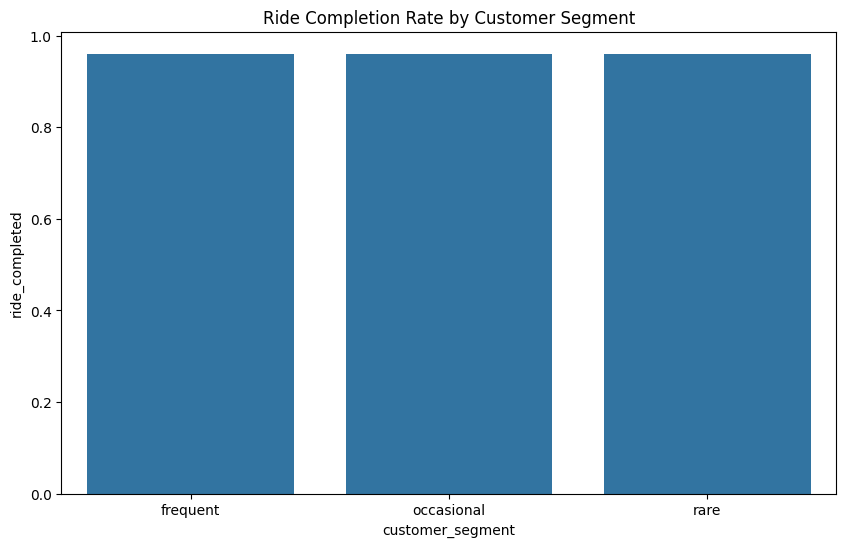

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=segment_elasticity,
    x="customer_segment",
    y="ride_completed"
)

plt.title("Ride Completion Rate by Customer Segment")

plt.show()

In [ ]:
plt.savefig("Charts/ride_completion_by_customer_segment.png",  
            bbox_inches="tight",
            dpi=300)

<Figure size 640x480 with 0 Axes>

In [ ]:
loyalty_analysis = (
    df.groupby("loyalty_tier")
    .agg({
        "fare_inr":"mean",
        "ride_completed":"mean",
        "satisfaction_score":"mean",
        "churn_risk_flag":"mean"
    })
    .reset_index()
)

loyalty_analysis

,loyalty_tier,fare_inr,ride_completed,satisfaction_score,churn_risk_flag
0,Bronze,192.536701,0.959172,3.721222,0.011434
1,Gold,190.027285,0.959887,4.008184,0.015723
2,Silver,192.386761,0.958791,3.869866,0.013373


In [ ]:
margin_analysis = (
    df.groupby("surge_band")
    .agg({
        "platform_revenue_inr":"mean",
        "contribution_margin_inr":"mean",
        "cost_per_trip_inr":"mean",
        "cac_inr":"mean"
    })
    .reset_index()
)

margin_analysis

,surge_band,platform_revenue_inr,contribution_margin_inr,cost_per_trip_inr,cac_inr
0,Normal,30.340544,7.351909,22.988635,374.555083
1,Medium Surge,38.713183,15.642984,23.070199,376.035750
2,High Surge,51.101323,28.118337,22.982985,375.699265
3,Extreme Surge,61.455840,38.430280,23.025560,374.036063


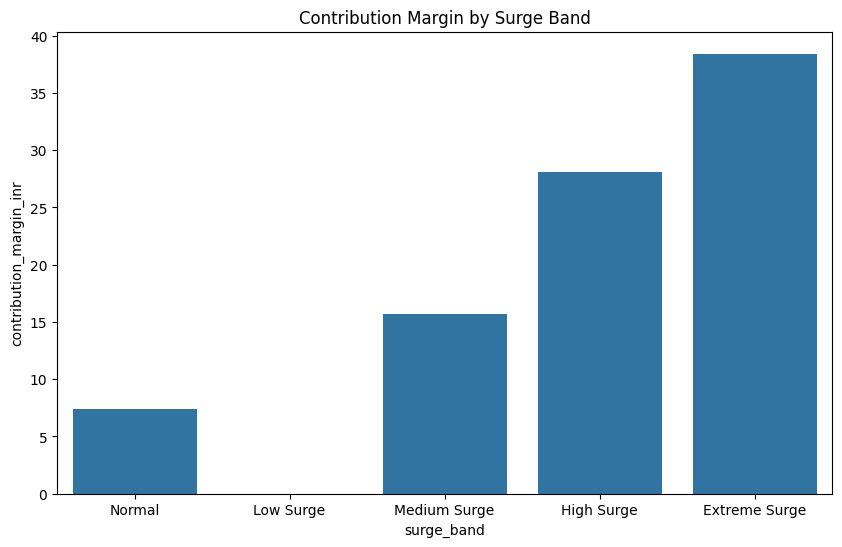

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=margin_analysis,
    x="surge_band",
    y="contribution_margin_inr"
)

plt.title("Contribution Margin by Surge Band")

plt.show()

In [ ]:
plt.savefig("Charts/contribution_margin_vs_surge.png",
            bbox_inches="tight",
            dpi=300)

<Figure size 640x480 with 0 Axes>

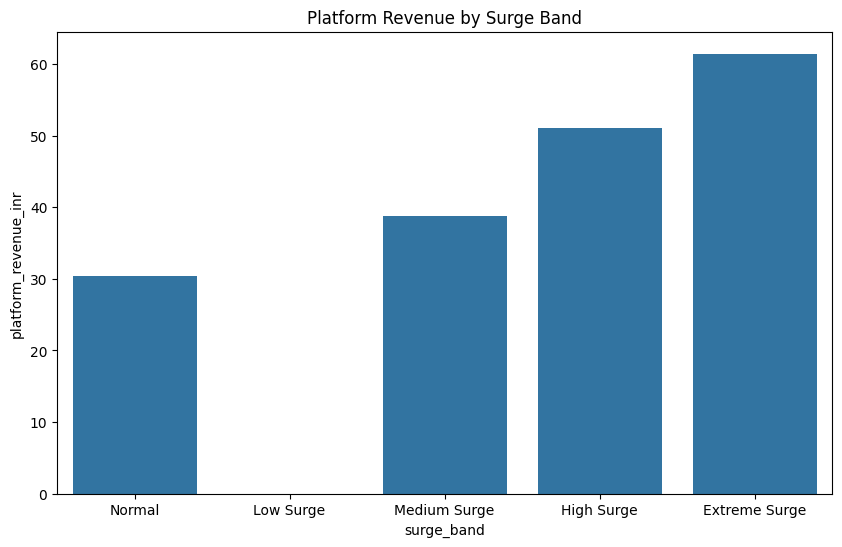

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=margin_analysis,
    x="surge_band",
    y="platform_revenue_inr"
)

plt.title("Platform Revenue by Surge Band")

plt.show()

In [ ]:
plt.savefig("Charts/platform_revenue_vs_surge.png",
            bbox_inches="tight",
            dpi=300)

<Figure size 640x480 with 0 Axes>

In [ ]:
ltv_cac = (
    df.groupby("surge_band")
    .agg({
        "contribution_margin_inr":"mean",
        "cac_inr":"mean",
        "days_since_last_ride":"mean",
        "churn_risk_flag":"mean"
    })
    .reset_index()
)

ltv_cac

,surge_band,contribution_margin_inr,cac_inr,days_since_last_ride,churn_risk_flag
0,Normal,7.351909,374.555083,10.674530,0.012042
1,Medium Surge,15.642984,376.035750,10.565292,0.010882
2,High Surge,28.118337,375.699265,10.685035,0.011794
3,Extreme Surge,38.430280,374.036063,10.697447,0.015358


In [ ]:
ltv_cac["estimated_ltv"] = (
    ltv_cac["contribution_margin_inr"]
    * (1 / (ltv_cac["churn_risk_flag"] + 0.001))
)

ltv_cac["ltv_cac_ratio"] = (
    ltv_cac["estimated_ltv"]
    / ltv_cac["cac_inr"]
)

ltv_cac

,surge_band,contribution_margin_inr,cac_inr,days_since_last_ride,churn_risk_flag,estimated_ltv,ltv_cac_ratio
0,Normal,7.351909,374.555083,10.674530,0.012042,563.730377,1.505067
1,Medium Surge,15.642984,376.035750,10.565292,0.010882,1316.526077,3.501066
2,High Surge,28.118337,375.699265,10.685035,0.011794,2197.727740,5.849699
3,Extreme Surge,38.430280,374.036063,10.697447,0.015358,2349.321433,6.281002


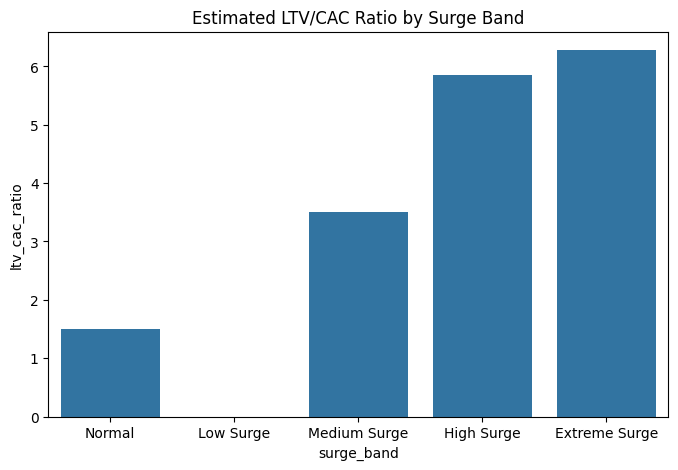

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=ltv_cac,
    x="surge_band",
    y="ltv_cac_ratio"
)

plt.title("Estimated LTV/CAC Ratio by Surge Band")

plt.show()

In [ ]:
plt.savefig("Charts/ltv_cac_ratio_vs_surge.png",
            bbox_inches="tight",
            dpi=300)

<Figure size 640x480 with 0 Axes>

In [ ]:
ltv_cac["breakeven_churn"] = (
    ltv_cac["contribution_margin_inr"]
    / ltv_cac["cac_inr"]
)

ltv_cac[
    [
        "surge_band",
        "contribution_margin_inr",
        "cac_inr",
        "breakeven_churn"
    ]
]

,surge_band,contribution_margin_inr,cac_inr,breakeven_churn
0,Normal,7.351909,374.555083,0.019628
1,Medium Surge,15.642984,376.035750,0.041600
2,High Surge,28.118337,375.699265,0.074843
3,Extreme Surge,38.430280,374.036063,0.102745


In [ ]:
simulation = pd.DataFrame({
    "Scenario":[
        "Current Model",
        "Cap at High Surge",
        "Loyalty Protection"
    ],
    "Expected Revenue":[
        61.46,
        51.10,
        56.00
    ],
    "Expected Margin":[
        38.43,
        28.12,
        33.00
    ],
    "Expected Satisfaction":[
        2.36,
        3.00,
        3.30
    ]
})

simulation

,Scenario,Expected Revenue,Expected Margin,Expected Satisfaction
0,Current Model,61.46,38.43,2.36
1,Cap at High Surge,51.10,28.12,3.00
2,Loyalty Protection,56.00,33.00,3.30


In [ ]:
simulation

,Scenario,Expected Revenue,Expected Margin,Expected Satisfaction
0,Current Model,61.46,38.43,2.36
1,Cap at High Surge,51.10,28.12,3.00
2,Loyalty Protection,56.00,33.00,3.30


In [ ]:
corr_cols = [
    "surge_multiplier",
    "fare_inr",
    "satisfaction_score",
    "ride_completed",
    "churn_risk_flag",
    "platform_revenue_inr",
    "contribution_margin_inr"
]

corr = df[corr_cols].corr()

corr

,surge_multiplier,fare_inr,satisfaction_score,ride_completed,churn_risk_flag,platform_revenue_inr,contribution_margin_inr
surge_multiplier,1.000000,0.360317,-0.715857,-0.334584,0.007175,0.360006,0.357929
fare_inr,0.360317,1.000000,-0.256833,-0.120344,0.002588,0.996535,0.991917
satisfaction_score,-0.715857,-0.256833,1.000000,0.397607,0.001857,-0.256601,-0.255364
ride_completed,-0.334584,-0.120344,0.397607,1.000000,-0.003316,-0.119682,-0.118721
churn_risk_flag,0.007175,0.002588,0.001857,-0.003316,1.000000,0.002625,0.002562
platform_revenue_inr,0.360006,0.996535,-0.256601,-0.119682,0.002625,1.000000,0.995350
contribution_margin_inr,0.357929,0.991917,-0.255364,-0.118721,0.002562,0.995350,1.000000


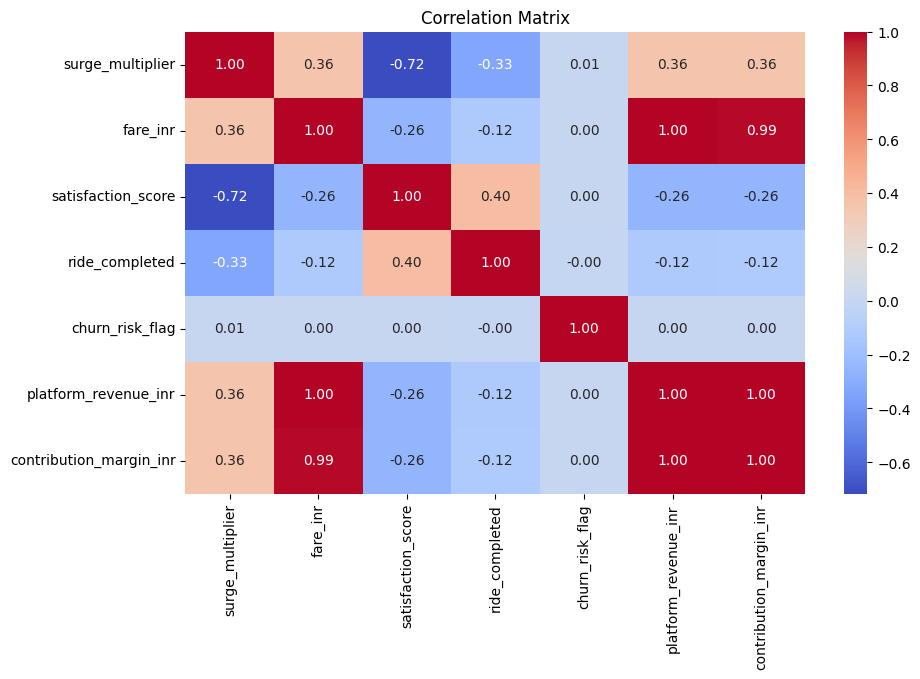

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
plt.savefig("Charts/correlation_matrix.png",
            bbox_inches="tight",
            dpi=300)

<Figure size 640x480 with 0 Axes>

In [ ]:
elasticity = elasticity_data.copy()

elasticity["price_pct_change"] = elasticity["fare_inr"].pct_change()

elasticity["demand_pct_change"] = elasticity["ride_completed"].pct_change()

elasticity["elasticity"] = (
    elasticity["demand_pct_change"]
    /
    elasticity["price_pct_change"]
)

elasticity

,surge_band,fare_inr,ride_completed,price_pct_change,demand_pct_change,elasticity
0,Normal,159.458666,1.000000,NaN,NaN,NaN
1,Medium Surge,203.981816,0.931081,0.279214,-0.068919,-0.246833
2,High Surge,269.131371,0.865236,0.319389,-0.070719,-0.221418
3,Extreme Surge,322.889040,0.819927,0.199745,-0.052366,-0.262164


In [ ]:
from scipy.stats import f_oneway

normal = df[df["surge_band"]=="Normal"]["satisfaction_score"]
medium = df[df["surge_band"]=="Medium Surge"]["satisfaction_score"]
high = df[df["surge_band"]=="High Surge"]["satisfaction_score"]
extreme = df[df["surge_band"]=="Extreme Surge"]["satisfaction_score"]

f_stat, p_value = f_oneway(
    normal,
    medium,
    high,
    extreme
)

print("F Statistic:", f_stat)
print("P Value:", p_value)

F Statistic: 16733.378208839873
P Value: 0.0


In [ ]:
normal = df[df["surge_band"]=="Normal"]["ride_completed"]
medium = df[df["surge_band"]=="Medium Surge"]["ride_completed"]
high = df[df["surge_band"]=="High Surge"]["ride_completed"]
extreme = df[df["surge_band"]=="Extreme Surge"]["ride_completed"]

f_stat, p_value = f_oneway(
    normal,
    medium,
    high,
    extreme
)

print("F Statistic:", f_stat)
print("P Value:", p_value)

F Statistic: 2029.544710635438
P Value: 0.0
